# Problem 2.50: Delayed-Input Digital Reverberator

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
Consider the following reverberator:
$$
y[n] = a y[n - D] + x[n - D]
$$
* **(a)** Explain the key difference between this reverberator and the one in (2.103):
  $$
  y[n] = x[n] + a y[n - D]
  $$
* **(b)** Write a function for the implementation of this reverberator that requires $D$ delays only.
* **(c)** Compute and plot the impulse response for $a = 0.7$ and compare with the impulse response of (2.103).
* **(d)** Experiment as in Problem 19 using `handel.wav` and compare the two reverberators.

In [2]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from IPython.display import Audio, display


## (a) Key Difference Between the Two Reverberators
- **Reverberator (2.103):**
  $$
  y_{\text{ref}}[n] = x[n] + a y_{\text{ref}}[n - D]
  $$
  The direct sound $x[n]$ is output immediately at $n=0$ without delay ($h[0] = 1$). It models listening to both the direct source sound and the subsequent room reflections (Dry + Wet).

- **Reverberator (Problem 50):**
  $$
  y_{\text{del}}[n] = a y_{\text{del}}[n - D] + x[n - D]
  $$
  The input itself is delayed by $D$ samples before entering the system. There is **no direct sound** at $n=0$ ($h[0] = 0$). The output is strictly the reverberated sound shifted in time by $D$ samples: $y_{\text{del}}[n] = y_{\text{ref}}[n - D]$.

## (b) Memory-Efficient Implementation with $D$ Delays Only
Notice that:
$$
y[n] = w[n - D], \quad \text{where } w[n] = x[n] + a y[n]
$$
Hence, a single circular buffer (delay line) of length $D$ is sufficient to hold the state, requiring only $D$ memory delay elements.

In [ ]:
def reverb_delayed_d(x: np.ndarray, D: int, a: float = 0.7) -> np.ndarray:
    """
    Implementation of y[n] = a * y[n - D] + x[n - D] using only D delay elements.
    """
    N = len(x)
    y = np.zeros(N, dtype=np.float64)
    # Circular delay buffer of length D
    delay_line = np.zeros(D, dtype=np.float64)

    for n in range(N):
        # Oldest sample in the buffer is w[n - D] = y[n]
        out = delay_line[n % D]
        y[n] = out
        # Next input to buffer is x[n] + a * y[n]
        delay_line[n % D] = x[n] + a * out

    return y

def reverb_reference(x: np.ndarray, D: int, a: float = 0.7) -> np.ndarray:
    """
    Reference reverberator (2.103): y[n] = x[n] + a * y[n - D]
    """
    N = len(x)
    y = np.zeros(N, dtype=np.float64)
    for n in range(N):
        y[n] = x[n]
        if n >= D:
            y[n] += a * y[n - D]
    return y


## (c) Impulse Response Comparison ($a = 0.7$)
We feed a unit impulse $\delta[n]$ ($N = 1000$ samples) with $D = 100$ and $a = 0.7$ to compute and plot the impulse responses.

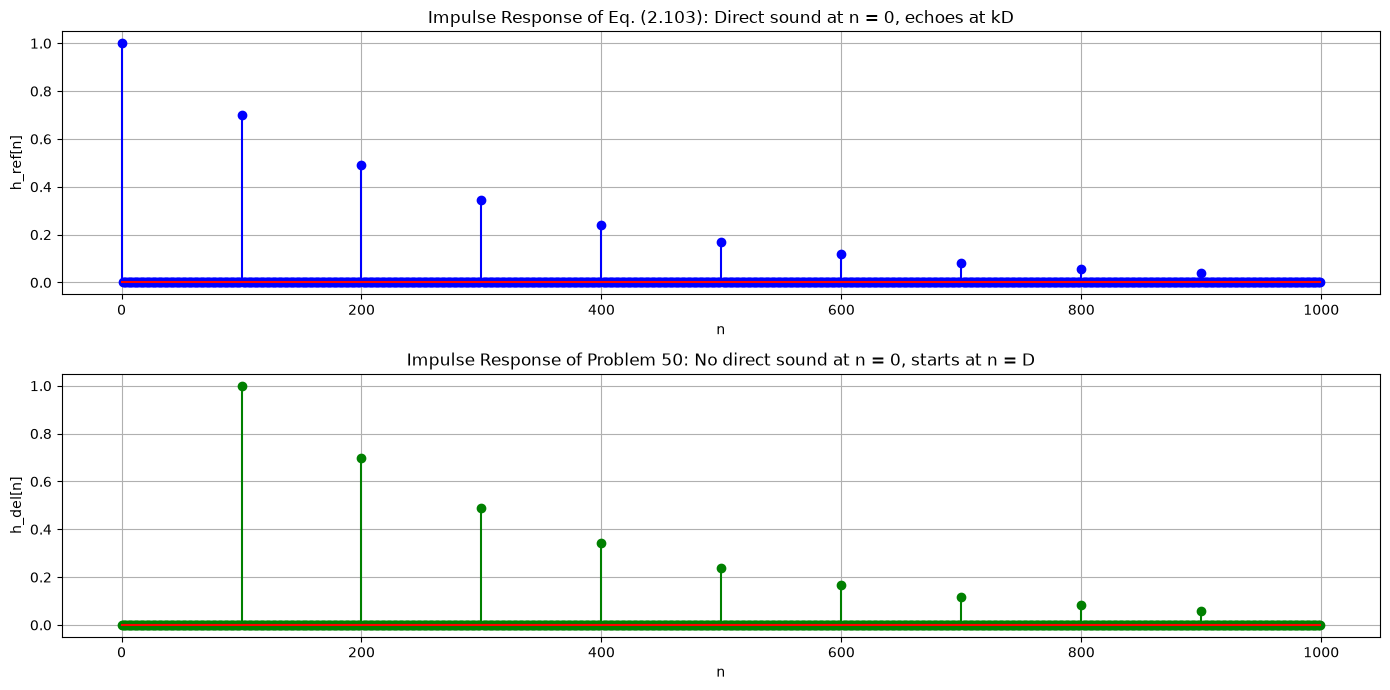

In [7]:
N_imp = 1000
D_test = 100
a_test = 0.7

delta = np.zeros(N_imp)
delta[0] = 1.0

h_ref = reverb_reference(delta, D_test, a_test)
h_del = reverb_delayed_d(delta, D_test, a_test)

n_axis = np.arange(N_imp)

plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.stem(n_axis, h_ref, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Impulse Response of Eq. (2.103): Direct sound at n = 0, echoes at kD')
plt.xlabel('n')
plt.ylabel('h_ref[n]')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(n_axis, h_del, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Impulse Response of Problem 50: No direct sound at n = 0, starts at n = D')
plt.xlabel('n')
plt.ylabel('h_del[n]')
plt.grid(True)

plt.tight_layout()
plt.show()


## (d) Audio Experiment on `handel.wav`
Listen and compare both reverberator implementations with delay $\tau = 50\text{ ms}$ ($D = 410$ samples) and $a = 0.7$.

In [9]:
wav_path = Path('handel.wav')
x, Fs = sf.read(wav_path)
D_audio = round(0.05 * Fs)  # 50 ms delay
a_val = 0.7

y_ref_audio = reverb_reference(x, D_audio, a_val)
y_del_audio = reverb_delayed_d(x, D_audio, a_val)

print("1. Original sound:")
display(Audio(x, rate=int(Fs)))

print("2. Reverberator (2.103) - with direct sound:")
display(Audio(y_ref_audio, rate=int(Fs)))

print("3. Reverberator (Problem 50) - delayed sound (no direct sound):")
display(Audio(y_del_audio, rate=int(Fs)))


1. Original sound:
<IPython.lib.display.Audio object>
2. Reverberator (2.103) - with direct sound:
<IPython.lib.display.Audio object>
3. Reverberator (Problem 50) - delayed sound (no direct sound):
<IPython.lib.display.Audio object>
